In this project we will try to answer different questions: \
In which year did the most attempts at breaking out of prison with a helicopter occur? \
In which countries do the most attempted helicopter prison escapes occur?

Import Data - Importation des données


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import requests

url = "https://en.wikipedia.org/wiki/List_of_helicopter_prison_escapes"
headers = {"User-Agent": "Mozilla/5.0"}
response = requests.get(url, headers=headers)

tables = pd.read_html(response.text)

/tmp/ipykernel_2590/1366141393.py:7: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


In [3]:
len(tables)
print(tables[0].head())
print(tables[1].head())
print(tables[2].head())

    0                                                  1
0 NaN  This list is incomplete; you can help by addin...
                Date                                   Prison name  \
0    August 19, 1971                         Santa Martha Acatitla   
1   October 31, 1973                         Mountjoy Jail, Dublin   
2       May 24, 1978  United States Penitentiary, Marion, Illinois   
3  February 27, 1981        Fleury-Mérogis, Essonne, Ile de France   
4        May 7, 1981               Orsainville Prison, Quebec City   

         Country Succeeded                                         Escapee(s)  \
0         Mexico       Yes  Joel David Kaplan Carlos Antonio Contreras Castro   
1        Ireland       Yes              JB O'Hagan Seamus Twomey Kevin Mallon   
2  United States        No  Garrett Brock Trapnell Martin Joseph McNally J...   
3         France       Yes                       Gérard Dupré Daniel Beaumont   
4         Canada        No  Marina Paquet (hijacker) Giles A

In [4]:
data=tables[1]

Analyzing Data - Analyse des données

In [5]:
data.head()

,Date,Prison name,Country,Succeeded,Escapee(s),Details
0,"August 19, 1971",Santa Martha Acatitla,Mexico,Yes,Joel David Kaplan Carlos Antonio Contreras Castro,Kaplan was a New York businessman who had been...
1,"October 31, 1973","Mountjoy Jail, Dublin",Ireland,Yes,JB O'Hagan Seamus Twomey Kevin Mallon,An IRA member hijacked a helicopter and forced...
2,"May 24, 1978","United States Penitentiary, Marion, Illinois",United States,No,Garrett Brock Trapnell Martin Joseph McNally J...,43-year-old Barbara Ann Oswald hijacked a Sain...
3,"February 27, 1981","Fleury-Mérogis, Essonne, Ile de France",France,Yes,Gérard Dupré Daniel Beaumont,"With the help of Serge Coutel, Dupré and Beaum..."
4,"May 7, 1981","Orsainville Prison, Quebec City",Canada,No,Marina Paquet (hijacker) Giles Arseneault (pri...,Paquet held a sawed-off shotgun against the ba...


In [6]:
for row in data[:]:
  print(row)

Date
Prison name
Country
Succeeded
Escapee(s)
Details


In [7]:
#Removing the Details (last column) - Supprimer la colonne détail
index=0
for row in data:
  #on prend tout sauf le dernier élément
  data[index]=row[:-1]


In [8]:
data["Date"]=pd.to_datetime(data["Date"], errors="coerce")

In [9]:
data.head()

,Date,Prison name,Country,Succeeded,Escapee(s),Details,0
0,1971-08-19,Santa Martha Acatitla,Mexico,Yes,Joel David Kaplan Carlos Antonio Contreras Castro,Kaplan was a New York businessman who had been...,Detail
1,1973-10-31,"Mountjoy Jail, Dublin",Ireland,Yes,JB O'Hagan Seamus Twomey Kevin Mallon,An IRA member hijacked a helicopter and forced...,Detail
2,1978-05-24,"United States Penitentiary, Marion, Illinois",United States,No,Garrett Brock Trapnell Martin Joseph McNally J...,43-year-old Barbara Ann Oswald hijacked a Sain...,Detail
3,1981-02-27,"Fleury-Mérogis, Essonne, Ile de France",France,Yes,Gérard Dupré Daniel Beaumont,"With the help of Serge Coutel, Dupré and Beaum...",Detail
4,1981-05-07,"Orsainville Prison, Quebec City",Canada,No,Marina Paquet (hijacker) Giles Arseneault (pri...,Paquet held a sawed-off shotgun against the ba...,Detail


In which year did the most attempts at breaking out of prison with a helicopter occur?

In [10]:
data["Year"]=data["Date"].dt.year

In [11]:
data["Year"].nunique() #31
attempts_per_year=data["Year"].value_counts().sort_index(ascending=False).reset_index()
attempts_per_year.columns=["Year", "Count"]
attempts_per_year.sort_values(by="Count", ascending=False)

,Year,Count
13,2001.0,3
8,2007.0,3
7,2009.0,3
23,1988.0,3
25,1986.0,3
12,2002.0,2
4,2013.0,2
26,1985.0,2
22,1989.0,2
14,2000.0,2


In [12]:
print(min(data["Year"]))
print(max(data["Year"]))

1971.0
2020.0


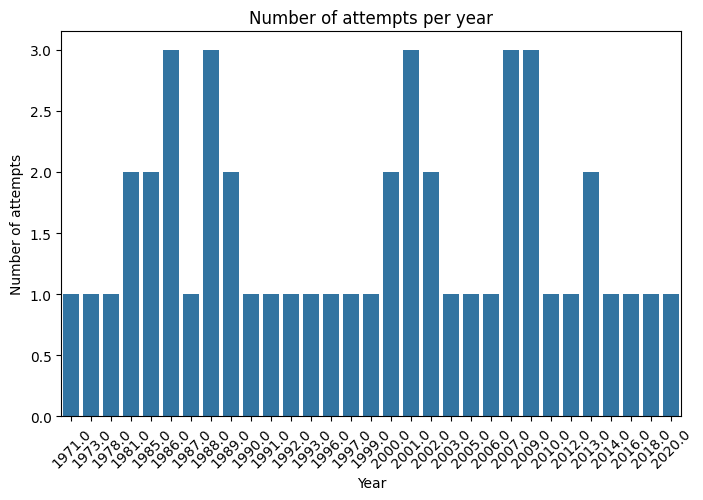

In [13]:
plt.figure(figsize=(8,5))
sns.barplot(data=attempts_per_year, x="Year", y="Count")
plt.xlabel("Year")
plt.ylabel("Number of attempts")
plt.title("Number of attempts per year")
plt.xticks(rotation=45);

Les années où il y a le plus de tentative d'évasion de prison par hélicoptères sont en 1986, 1988, 2001, 2007 et 2009.

In which countries do the most attempted helicopter prison escapes occur?

In [14]:
attempts_per_country=data["Country"].value_counts().reset_index()
attempts_per_country.columns=["Country", "Count"]
attempts_per_country.sort_values(by="Count", ascending=False)

,Country,Count
0,France,15
1,United States,8
2,Canada,4
3,Belgium,4
4,Greece,4
5,United Kingdom,2
6,Brazil,2
7,Australia,2
8,Colombia,2
9,Italy,1


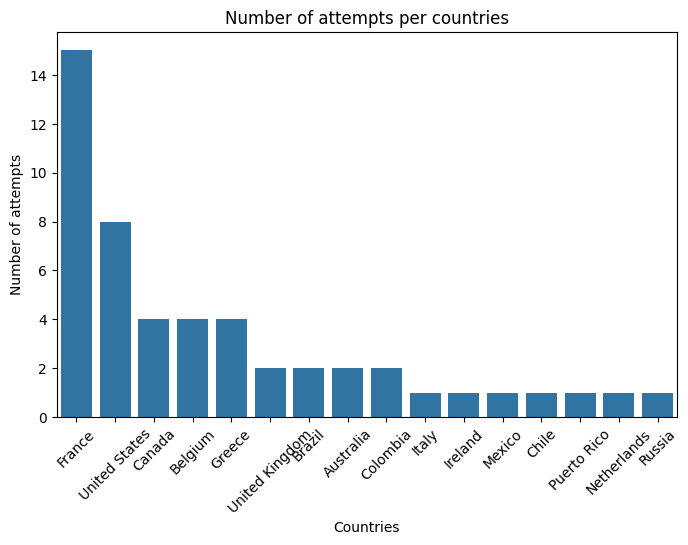

In [15]:
plt.figure(figsize=(8,5))
sns.barplot(data=attempts_per_country, x="Country", y="Count")
plt.xlabel("Countries")
plt.ylabel("Number of attempts")
plt.title("Number of attempts per countries")
plt.xticks(rotation=45);

Les pays où il y a le plus tentative d'évasions sont la France avec 15 tentaives, suivi par les Etats-Unis avec 8 tentatives.

In which countries do helicopter prison breaks have a higher chance of success?


In [17]:
data["Success_num"]=data["Succeeded"].map({"Yes":1, "No":0})
country_analysis=data.groupby("Country").agg(Success_rate=("Success_num", "mean"), Attempts=("Success_num", "count"))
country_analysis.sort_values("Success_rate", ascending=False)

,Success_rate,Attempts
Country,,
Brazil,1.000000,2
Chile,1.000000,1
Colombia,1.000000,2
Russia,1.000000,1
Puerto Rico,1.000000,1
Mexico,1.000000,1
Italy,1.000000,1
Ireland,1.000000,1
Canada,0.750000,4
